# NPL **with EM** for Latent Financial Literacy (Full State Space)

This notebook implements **Nested Pseudo-Likelihood (NPL)** with an **EM** inner loop to recover latent literacy types and per-person posteriors.


In [1]:
import numpy as np, pandas as pd, json, os, itertools
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, linewidth=130)

BETA = 0.96
X_GRID = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
J = len(X_GRID)
A_BINS, Y_BINS, AGE_BINS = 6, 4, 4
ALPHA = 5.0
EULER_GAMMA = 0.5772156649015329
CSV_PATH = 'toy_panel_with_random_x.csv'
RNG = np.random.default_rng(7)


## 1) Load or create data (synthetic fallback)


In [2]:
if not os.path.exists(CSV_PATH):
    N, T = 150, 5
    k0_true = 30.0
    kL_true = np.array([25.0, 5.0])
    phiL_true = np.array([0.010, 0.002])
    pi_true = np.array([0.5, 0.5])
    ids = np.arange(N)
    L = np.random.default_rng(3).choice([0,1], size=N, p=pi_true)
    rows = []
    for i in ids:
        a = float(np.random.default_rng(i).lognormal(mean=10.0, sigma=0.35))
        y = float(np.random.default_rng(i+1).lognormal(mean=10.0, sigma=0.25))
        age = int(np.random.default_rng(i+2).integers(25, 60))
        for t in range(T):
            idx = np.zeros(J)
            for j in range(1, J):
                bump = 15.0 * np.sqrt(X_GRID[j])
                cost = k0_true + kL_true[L[i]] + phiL_true[L[i]] * a
                idx[j] = -cost + BETA * bump
            idx[0] = 0.0
            m = np.max(idx); p = np.exp(idx - m); p = p/p.sum()
            j = np.random.default_rng(i+3+t).choice(J, p=p)
            x = float(X_GRID[j])
            a = float(max(1.0, a * (1.02 + 0.01*(x>0)) + np.random.default_rng(i+4+t).normal(0, 800)))
            y = float(max(1.0, y * (1.01 + np.random.default_rng(i+5+t).normal(0, 0.02))))
            age += 1
            rows.append({"id": int(i), "t": int(t), "age": int(age), "a": a, "y": y, "x": x})
    pd.DataFrame(rows).to_csv(CSV_PATH, index=False)

df = pd.read_csv(CSV_PATH)
df.head(6)


,id,t,age,a,y,x
0,0,0,55,22956.311480,23869.078491,0.0
1,0,1,56,22773.892569,24610.507328,0.0
2,0,2,57,24071.863024,24857.217895,0.0
3,0,3,58,24554.284408,24241.620741,0.0
4,0,4,59,23654.756977,24094.795579,0.0
5,1,0,54,24714.110708,23809.810725,0.0


In [3]:
df.describe()

,id,t,age,a,y,x
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.0
mean,74.500000,2.000000,45.780000,23140.574952,22316.465625,0.0
std,43.329204,1.415157,10.203451,8888.765465,5826.706562,0.0
min,0.000000,0.000000,26.000000,7570.507923,11758.393851,0.0
25%,37.000000,1.000000,38.000000,16125.132553,17702.463186,0.0
50%,74.500000,2.000000,46.000000,21470.980250,21285.526423,0.0
75%,112.000000,3.000000,54.000000,27747.859718,25543.827425,0.0
max,149.000000,4.000000,64.000000,67502.037318,47978.137392,0.0


## 2) Helpers


In [4]:
def quantile_bins(series, nbins):
    qs = np.linspace(0,1,nbins+1)
    cuts = series.quantile(qs).values.astype(float)
    for i in range(1,len(cuts)):
        if cuts[i] <= cuts[i-1]:
            cuts[i] = cuts[i-1] + 1e-9
    return cuts

def cut_to_bins(x, cuts):
    return int(np.clip(np.searchsorted(cuts, x, side='right')-1, 0, len(cuts)-2))

def dirichlet_smooth(counts, alpha=5.0):
    counts = np.asarray(counts, float)
    prior = alpha/len(counts)
    return (counts + prior) / (counts.sum()+alpha)

def softmax(v):
    v = np.asarray(v, float) - np.max(v)
    ex = np.exp(v)
    return ex/ex.sum()

def safe_normalize(v):
    v = np.asarray(v, float)
    s = v.sum()
    return (v/s) if s>0 else np.ones_like(v)/len(v)


## 3) Discretize states/actions; add next-period bins


In [5]:
a_cuts = quantile_bins(df['a'], A_BINS)
y_cuts = quantile_bins(df['y'], Y_BINS)
age_cuts = quantile_bins(df['age'], AGE_BINS)

dfb = df.copy()
dfb['ia']   = dfb['a'].apply(lambda v: cut_to_bins(v, a_cuts))
dfb['iy']   = dfb['y'].apply(lambda v: cut_to_bins(v, y_cuts))
dfb['iage'] = dfb['age'].apply(lambda v: cut_to_bins(v, age_cuts))

def x_to_j(x):
    return int(np.argmin(np.abs(X_GRID - float(x))))
dfb['j'] = dfb['x'].apply(x_to_j)

dfb = dfb.sort_values(['id','t']).reset_index(drop=True)
for col in ['ia','iy','iage','j']:
    dfb[col+'_next'] = dfb.groupby('id')[col].shift(-1)
dfb = dfb.dropna(subset=['ia_next','iy_next','iage_next']).copy()
for col in ['ia_next','iy_next','iage_next','j_next']:
    dfb[col] = dfb[col].astype(int)

dfb.head(5)


,id,t,age,a,y,x,ia,iy,iage,j,ia_next,iy_next,iage_next,j_next
0,0,0,55,22956.311480,23869.078491,0.0,3,2,3,0,3,2,3,0
1,0,1,56,22773.892569,24610.507328,0.0,3,2,3,0,3,2,3,0
2,0,2,57,24071.863024,24857.217895,0.0,3,2,3,0,3,2,3,0
3,0,3,58,24554.284408,24241.620741,0.0,3,2,3,0,3,2,3,0
5,1,0,54,24714.110708,23809.810725,0.0,3,2,3,0,4,2,3,0


## 4) Full state space & action-specific transitions


In [6]:
states = [(ia,iy,iage) for ia in range(A_BINS) for iy in range(Y_BINS) for iage in range(AGE_BINS)]
S = len(states) # 6x4x4 = 96
s_index = {s:i for i,s in enumerate(states)}

Pi_counts = [np.zeros((S,S), float) for _ in range(J)]
row_counts = [np.zeros(S, float) for _ in range(J)]
for _, r in dfb.iterrows():
    s  = s_index[(int(r.ia), int(r.iy), int(r.iage))]
    sp = s_index[(int(r.ia_next), int(r.iy_next), int(r.iage_next))]
    j  = int(r.j)
    Pi_counts[j][s, sp] += 1.0
    row_counts[j][s] += 1.0

global_next_counts_by_j = [Pi_counts[j].sum(axis=0) for j in range(J)]
global_next_counts_all = sum(global_next_counts_by_j)
global_next_dist_by_j = [safe_normalize(c) for c in global_next_counts_by_j]
global_next_dist_all = safe_normalize(global_next_counts_all)

Pi = [np.zeros((S,S), float) for _ in range(J)]
for j in range(J):
    for s in range(S):
        if row_counts[j][s] > 0:
            Pi[j][s,:] = Pi_counts[j][s,:] / row_counts[j][s]
        else:
            base = global_next_dist_by_j[j]
            Pi[j][s,:] = base if base.sum()>0 else global_next_dist_all

S, len(Pi)


(96, 5)

In [29]:
states[:5]

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0)]

In [38]:
np.shape(Pi[0])

(96, 96)

In [31]:
Pi[0]

array([[0.        , 1.        , 0.        , ..., 0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        , 0.        ],
       [0.        , 0.02898551, 0.        , ..., 0.        , 0.        , 0.        ],
       ...,
       [0.        , 0.02898551, 0.        , ..., 0.        , 0.        , 0.        ],
       [0.        , 0.02898551, 0.        , ..., 0.        , 0.        , 0.        ],
       [0.        , 0.02898551, 0.        , ..., 0.        , 0.        , 0.        ]])

## 5) Initial CCPs on full state space


In [7]:
counts = np.zeros((S,J), float)
for _, r in dfb.iterrows():
    s = s_index[(int(r.ia), int(r.iy), int(r.iage))]
    counts[s, int(r.j)] += 1.0

global_ccp = dirichlet_smooth(counts.sum(axis=0), alpha=ALPHA)
P0 = np.zeros((S,J), float)
for s in range(S):
    P0[s,:] = dirichlet_smooth(counts[s,:], alpha=ALPHA) if counts[s,:].sum()>0 else global_ccp

P0.shape


(96, 5)

## 6) Utilities and CCP operator


In [8]:
a_mids = np.array([0.5*(a_cuts[b]+a_cuts[b+1]) for b in range(len(a_cuts)-1)], float)

def u_vector_by_type(theta, L):
    # theta = [k0, k1_low, k1_high, phi_low, phi_high]
    k0, k1_low, k1_high, phi_low, phi_high = theta
    k1  = k1_low  if L==0 else k1_high
    phi = phi_low if L==0 else phi_high
    U = np.zeros((S,J), float)
    for si,(ia,iy,iage) in enumerate(states):
        a_mid = a_mids[ia]
        for j in range(1, J):
            U[si, j] = - (k0 + k1 + phi * a_mid)
        U[si, 0] = 0.0
    return U

def correction_e(Pmat):
    """EV1 correction e = γ - log P with stabilized CCPs."""
    eps = 1e-12
    return EULER_GAMMA - np.log(np.clip(Pmat, eps, 1.0))

def Pi_uncond(Pmat):
    """
    Unconditional transition Π(P): for each s, M[s,:] = sum_j P(s,j)*Π(j)[s,:].
    Uses broadcasting (no diag @) and enforces row-stochasticity.
    """
    M = np.zeros((S,S), float)
    for j in range(J):
        M += np.diag(Pmat[:,j]) @ Pi[j]
    return M

def phi_single(Pmat, theta, L):
    U = u_vector_by_type(theta, L)
    E = correction_e(Pmat)
    rhs = np.sum(Pmat * (U + E), axis=1)
    M = Pi_uncond(Pmat)
    I = np.eye(S)
    V = np.linalg.solve(I - BETA*M, rhs)
    return V

def Lambda_single(V, theta, L):
    """Stable policy update: logit index + robust softmax."""
    U = u_vector_by_type(theta, L)
    idx = np.zeros_like(U)
    for j in range(J):
        idx[:, j] = U[:, j] + BETA * (Pi[j] @ V)
    Ptil = np.zeros_like(idx)
    for s in range(S):
        Ptil[s, :] = softmax(idx[s, :])
    return Ptil

def Psi_single(Pmat, theta, L):
    """Ψ = Λ ∘ φ  (uses the robust Pi_uncond and correction_e defined above)."""
    return Lambda_single(phi_single(Pmat, theta, L), theta, L)


In [42]:
a_mids

array([13475.12399114, 18528.46930253, 21844.25014156, 25021.13732821, 31514.7588551 , 44983.9950036 ])

In [43]:
a_cuts

array([10038.83145534, 16911.41652695, 20145.52207812, 23542.978205  , 26499.29645142, 36530.22125878, 53437.76874842])

## 7) Person-level sequences


In [9]:
seq = {}
for pid, g in dfb.groupby('id'):
    sj = []
    for _, r in g.iterrows():
        s_idx = s_index[(int(r.ia), int(r.iy), int(r.iage))]
        sj.append((s_idx, int(r.j)))
    if sj:
        seq[int(pid)] = sj

len(seq), list(seq.keys())[:5]


(150, [0, 1, 2, 3, 4])

In [10]:
seq

{0: [(59, 0), (59, 0), (59, 0), (59, 0)],
 1: [(59, 0), (75, 0), (75, 0), (75, 0)],
 2: [(62, 0), (78, 0), (62, 0), (63, 0)],
 3: [(86, 0), (86, 0), (86, 0), (86, 0)],
 4: [(21, 0), (17, 0), (21, 0), (21, 0)],
 5: [(31, 0), (31, 0), (31, 0), (31, 0)],
 6: [(90, 0), (90, 0), (90, 0), (91, 0)],
 7: [(49, 0), (49, 0), (49, 0), (65, 0)],
 8: [(6, 0), (7, 0), (7, 0), (7, 0)],
 9: [(32, 0), (32, 0), (32, 0), (32, 0)],
 10: [(26, 0), (10, 0), (10, 0), (26, 0)],
 11: [(59, 0), (59, 0), (59, 0), (59, 0)],
 12: [(60, 0), (60, 0), (60, 0), (60, 0)],
 13: [(95, 0), (95, 0), (95, 0), (95, 0)],
 14: [(65, 0), (65, 0), (66, 0), (66, 0)],
 15: [(6, 0), (6, 0), (6, 0), (7, 0)],
 16: [(47, 0), (47, 0), (31, 0), (47, 0)],
 17: [(86, 0), (86, 0), (86, 0), (86, 0)],
 18: [(39, 0), (39, 0), (43, 0), (39, 0)],
 19: [(36, 0), (52, 0), (53, 0), (41, 0)],
 20: [(42, 0), (58, 0), (43, 0), (59, 0)],
 21: [(64, 0), (48, 0), (64, 0), (64, 0)],
 22: [(13, 0), (13, 0), (13, 0), (13, 0)],
 23: [(77, 0), (77, 0), (77, 

## 8) NPL outer loop with EM inside the PL step


In [15]:
def weighted_loglik_both_types(theta, Pk, omega):
    """
    Pseudo log-likelihood ∑_i ∑_t [ ω_i0 log P0(j_it|s_it) + ω_i1 log P1(j_it|s_it) ],
    where Pℓ = Ψ(Pk, θ, ℓ) and ω_iℓ are person-level responsibilities.
    """
    P0 = Psi_single(Pk, theta, 0)
    P1 = Psi_single(Pk, theta, 1)
    eps = 1e-12
    ll = 0.0
    for i, sj in seq.items():
        s_idx = [s for (s, j) in sj]
        j_idx = [j for (s, j) in sj]
        ll_i0 = np.sum(np.log(np.maximum(P0[s_idx, j_idx], eps)))
        ll_i1 = np.sum(np.log(np.maximum(P1[s_idx, j_idx], eps)))
        w0, w1 = omega.get(i, np.array([0.5,0.5]))
        ll += w0 * ll_i0 + w1 * ll_i1
    return float(ll)

def em_step(Pk, theta, pi_low, em_iters=2):
    """
    Holds Pk fixed. Alternates:
      E: ω_iℓ ∝ π_ℓ * ∏_t Pℓ(j_it|s_it),
      M (π): π_ℓ = mean_i ω_iℓ,
      M (θ): maximize responsibility-weighted pseudo-LL (demo: random search).
    Returns updated (theta, pi_low, P_low, P_high, omega).
    """
    pi = np.array([pi_low, 1.0 - pi_low], float)
    for _ in range(em_iters):
        P0 = Psi_single(Pk, theta, 0)
        P1 = Psi_single(Pk, theta, 1)
        omega = {}
        eps = 1e-12
        for i, sj in seq.items():
            s_idx = [s for (s, j) in sj]
            j_idx = [j for (s, j) in sj]
            ll0 = np.sum(np.log(np.maximum(P0[s_idx, j_idx], eps)))
            ll1 = np.sum(np.log(np.maximum(P1[s_idx, j_idx], eps)))
            m = max(ll0, ll1)
            num0 = pi[0] * np.exp(ll0 - m)
            num1 = pi[1] * np.exp(ll1 - m)
            den  = num0 + num1
            omega[i] = np.array([num0/den, num1/den]) if den>0 else np.array([0.5,0.5])
        mat = np.stack(list(omega.values()))
        pi = mat.mean(axis=0); pi = pi/np.sum(pi)
        rng = np.random.default_rng(0) # TODO: use a real optimizer
        best = theta.copy()
        best_val = weighted_loglik_both_types(best, Pk, omega)
        for it in range(200):
            theta_hat = best + rng.normal(0, [1.0, 1.0, 1.0, 0.0005, 0.0005], size=5)
            theta_hat[0]   = np.clip(theta_hat[0],   -50, 100)
            theta_hat[1:3] = np.clip(theta_hat[1:3], -50, 100)
            theta_hat[3:5] = np.clip(theta_hat[3:5], -0.05, 0.05)
            val = weighted_loglik_both_types(theta_hat, Pk, omega)
            if val > best_val:
                best, best_val = theta_hat, val
        theta = best
    P0 = Psi_single(Pk, theta, 0)
    P1 = Psi_single(Pk, theta, 1)
    return theta, float(pi[0]), P0, P1, omega

theta  = np.array([15.0, 12.0, 4.0, 0.008, 0.003])
pi_low = 0.5
Pk     = P0.copy()
tol    = 1e-4
history = []
MAX_ITERS = 10

for it in range(MAX_ITERS):
    theta, pi_low, P_low, P_high, omega = em_step(Pk, theta, pi_low, em_iters=10)
    Pmix = pi_low * P_low + (1.0 - pi_low) * P_high
    supdiff = float(np.max(np.abs(Pmix - Pk)))
    history.append({'iter': it, 'supnorm': supdiff, 'pi_low': float(pi_low), 'theta': list(map(float, theta))})
    Pk = Pmix
    if supdiff < tol:
        break

theta_hat  = theta
pi_low_hat = float(pi_low)
P_hat      = Pk
hist_df    = pd.DataFrame(history)
hist_df


,iter,supnorm,pi_low,theta
0,0,6.666667e-01,0.5,"[15.0, 12.0, 4.0, 0.008, 0.003]"
1,1,4.302156e-24,0.5,"[15.0, 12.0, 4.0, 0.008, 0.003]"


In [16]:
omega

{0: array([0.5, 0.5]),
 1: array([0.5, 0.5]),
 2: array([0.5, 0.5]),
 3: array([0.5, 0.5]),
 4: array([0.5, 0.5]),
 5: array([0.5, 0.5]),
 6: array([0.5, 0.5]),
 7: array([0.5, 0.5]),
 8: array([0.5, 0.5]),
 9: array([0.5, 0.5]),
 10: array([0.5, 0.5]),
 11: array([0.5, 0.5]),
 12: array([0.5, 0.5]),
 13: array([0.5, 0.5]),
 14: array([0.5, 0.5]),
 15: array([0.5, 0.5]),
 16: array([0.5, 0.5]),
 17: array([0.5, 0.5]),
 18: array([0.5, 0.5]),
 19: array([0.5, 0.5]),
 20: array([0.5, 0.5]),
 21: array([0.5, 0.5]),
 22: array([0.5, 0.5]),
 23: array([0.5, 0.5]),
 24: array([0.5, 0.5]),
 25: array([0.5, 0.5]),
 26: array([0.5, 0.5]),
 27: array([0.5, 0.5]),
 28: array([0.5, 0.5]),
 29: array([0.5, 0.5]),
 30: array([0.5, 0.5]),
 31: array([0.5, 0.5]),
 32: array([0.5, 0.5]),
 33: array([0.5, 0.5]),
 34: array([0.5, 0.5]),
 35: array([0.5, 0.5]),
 36: array([0.5, 0.5]),
 37: array([0.5, 0.5]),
 38: array([0.5, 0.5]),
 39: array([0.5, 0.5]),
 40: array([0.5, 0.5]),
 41: array([0.5, 0.5]),
 4

## 9) Person-level literacy posteriors and summary


In [17]:
P_low_final  = Psi_single(P_hat, theta_hat, 0)
P_high_final = Psi_single(P_hat, theta_hat, 1)

post = []
eps = 1e-12
for i, sj in seq.items():
    s_idx = [s for (s, j) in sj]
    j_idx = [j for (s, j) in sj]
    ll0 = np.sum(np.log(np.maximum(P_low_final[s_idx, j_idx],  eps)))
    ll1 = np.sum(np.log(np.maximum(P_high_final[s_idx, j_idx], eps)))
    m = max(ll0, ll1)
    num0 = pi_low_hat * np.exp(ll0 - m)
    num1 = (1.0 - pi_low_hat) * np.exp(ll1 - m)
    den = num0 + num1
    p_low  = num0/den if den>0 else 0.5
    p_high = num1/den if den>0 else 0.5
    post.append({'id': int(i), 'p_low': float(p_low), 'p_high': float(p_high)})

post_df = pd.DataFrame(post).sort_values('id').reset_index(drop=True)
summary = {'theta_hat': list(map(float, theta_hat)), 'pi_low_hat': float(pi_low_hat)}
print(json.dumps(summary, indent=2))
post_df.head(10)

out_path = 'literacy_posteriors_npl.csv'
post_df.to_csv(out_path, index=False)
print('Saved:', out_path)


{
  "theta_hat": [
    15.0,
    12.0,
    4.0,
    0.008,
    0.003
  ],
  "pi_low_hat": 0.5
}
Saved: literacy_posteriors_npl.csv


## 10) Diagnostics and visual checks


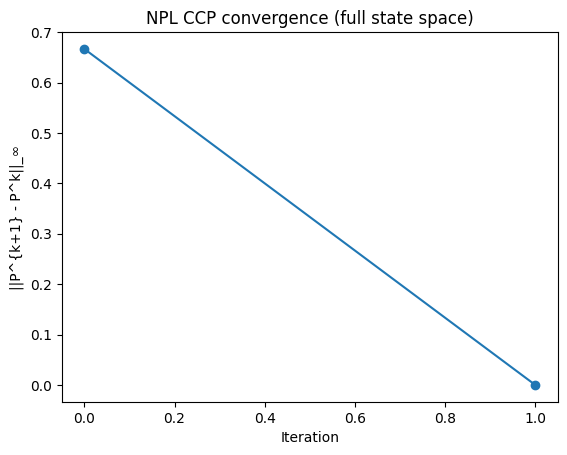

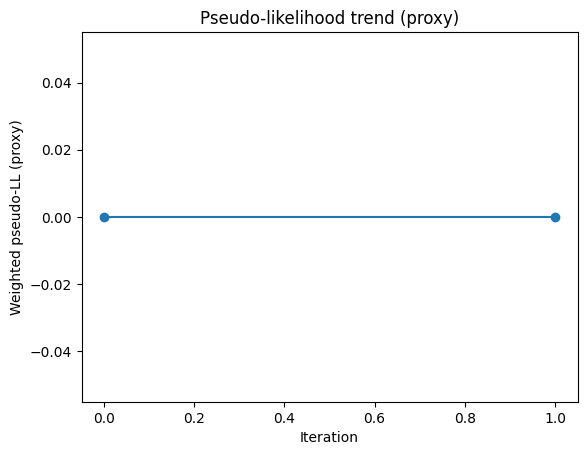

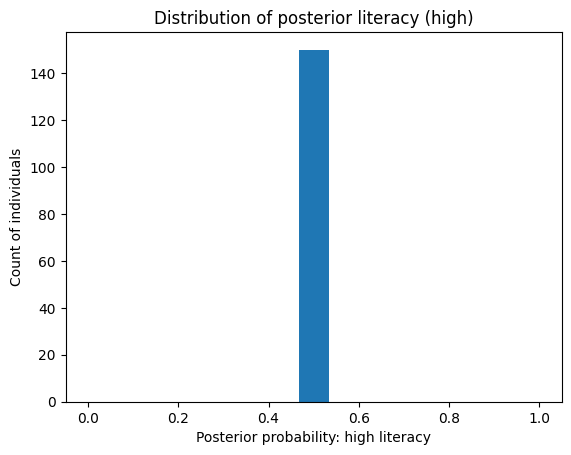

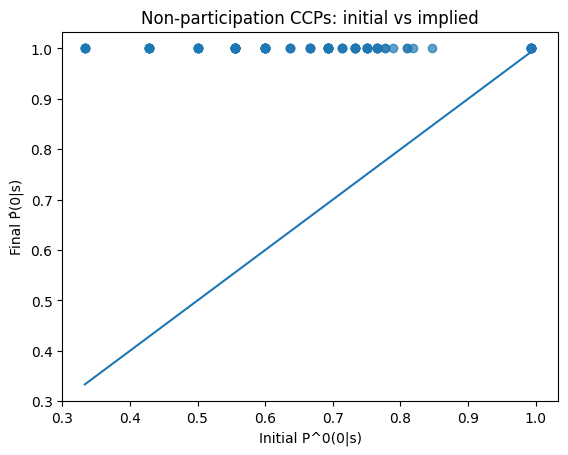

In [19]:
# 1) CCP sup-norm convergence
plt.figure()
plt.plot(hist_df['iter'].values, hist_df['supnorm'].values, marker='o')
plt.xlabel('Iteration'); plt.ylabel('||P^{k+1} - P^k||_∞'); plt.title('NPL CCP convergence (full state space)')
plt.show()

# 2) Proxy pseudo-LL trend
def weighted_loglik_both_types_proxy(Pk):
    # quick proxy using equal responsibilities (for plotting trend only)
    omega = {i: np.array([0.5,0.5]) for i in seq.keys()}
    theta0 = np.array([15.0, 12.0, 4.0, 0.008, 0.003])
    return weighted_loglik_both_types(theta0, Pk, omega)

vals = []
Pk_tmp = P0.copy(); theta_tmp = np.array([15.0, 12.0, 4.0, 0.008, 0.003]); pi_tmp = 0.5
for it in range(len(hist_df)):
    theta_tmp, pi_tmp, P_low_tmp, P_high_tmp, omega_tmp = em_step(Pk_tmp, theta_tmp, pi_tmp, em_iters=10)
    Pmix_tmp = pi_tmp * P_low_tmp + (1.0 - pi_tmp) * P_high_tmp
    vals.append(weighted_loglik_both_types(theta_tmp, Pk_tmp, omega_tmp))
    Pk_tmp = Pmix_tmp
plt.figure()
plt.plot(np.arange(len(vals)), vals, marker='o')
plt.xlabel('Iteration'); plt.ylabel('Weighted pseudo-LL (proxy)'); plt.title('Pseudo-likelihood trend (proxy)')
plt.show()

# 3) Posterior high-literacy histogram
plt.figure()
plt.hist(post_df['p_high'].values, bins=15)
plt.xlabel('Posterior probability: high literacy'); plt.ylabel('Count of individuals');
plt.title('Distribution of posterior literacy (high)')
plt.show()

# 4) Initial vs final P(0|s)
emp_P0 = P0[:,0].copy(); imp_P0 = P_hat[:,0].copy()
plt.figure()
plt.scatter(emp_P0, imp_P0, alpha=0.7)
mn = min(emp_P0.min(), imp_P0.min()); mx = max(emp_P0.max(), imp_P0.max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel('Initial P^0(0|s)'); plt.ylabel('Final P̂(0|s)'); plt.title('Non-participation CCPs: initial vs implied')
plt.show()
